In [33]:

from PIL import Image
from numpy import array, loadtxt, genfromtxt
import numpy as np
from project2_functions import sfm, camera, stereo
import matplotlib.pyplot as plt

# Load the oxford images
im1 = array(Image.open("./data/images/001.jpg"))
im2 = array(Image.open("./data/images/002.jpg"))

# load 2D points for each view to a list
points2D = [loadtxt('./data/2D/00'+str(i+1)+'.corners').T for i in range(3)]
# load 3D points
points3D = loadtxt('./data/3D/p3d').T
# load correspondences
corr = genfromtxt('./data/2D/nview-corners',
                  dtype=int,
                  missing_values='*',
                  filling_values=-1)

# load cameras to a list of Camera objects
P = [camera.Camera(loadtxt('./data/2D/00' + str(i + 1) + '.P')) for i in range(3)]

True


In [34]:
# ------------------------------------------
# 1. Select points visible in view 1 and view 2
# ------------------------------------------

pair_mask = (corr[:, 0] >= 0) & (corr[:, 1] >= 0)
pair_ids = np.where(pair_mask)[0]

x1 = points2D[0][:, corr[pair_mask, 0]]
x2 = points2D[1][:, corr[pair_mask, 1]]

x1 = np.vstack((x1, np.ones(x1.shape[1])))
x2 = np.vstack((x2, np.ones(x2.shape[1])))

In [35]:
# ------------------------------------------
# 2. Use Oxford camera matrices for the first pair
# ------------------------------------------

P1 = P[0].P
P2 = P[1].P

In [36]:
# ------------------------------------------
# 3. Triangulate 3D points from view 1 and view 2
# ------------------------------------------

X = sfm.triangulate(x1, x2, P1, P2)

# Normalize homogeneous coordinates
X = X / X[3]

In [37]:
# -------------------------------------------
# 4. Find which of those same 3D points are visible in view 3
# -------------------------------------------

visible_in_view3 = corr[pair_ids, 2] >= 0

X_for_P3 = X[:, visible_in_view3]

x3 = points2D[2][:, corr[pair_ids[visible_in_view3], 2]]
x3 = np.vstack((x3, np.ones(x3.shape[1])))

In [39]:
#-------------------------------------------
# 5. Compute camera 3 by resection
#-------------------------------------------

P3 = sfm.compute_P(x3, X_for_P3)

# Optional: normalize P3 scale
P3 = P3 / P3[-1, -1]

In [40]:
#-------------------------------------------
# 6. Camera centers
#-------------------------------------------

C1 = sfm.camera_center(P1)
C2 = sfm.camera_center(P2)
C3 = sfm.camera_center(P3)

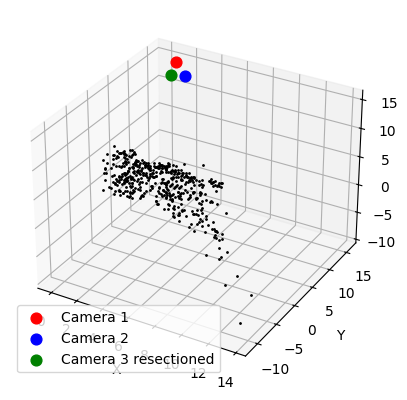

In [41]:
#-------------------------------------------
# 7. Plot
#-------------------------------------------

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Remove extreme/invalid points for plotting
valid = np.isfinite(X).all(axis=0)
Xp = X[:, valid]

ax.plot(Xp[0], Xp[1], Xp[2], "k.", markersize=2)

ax.scatter(*C1, c="r", s=60, label="Camera 1")
ax.scatter(*C2, c="b", s=60, label="Camera 2")
ax.scatter(*C3, c="g", s=60, label="Camera 3 resectioned")

ax.legend()
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [42]:
print("X min/max:", X[:3].min(), X[:3].max())
print("C1:", C1)
print("C2:", C2)
print("C3:", C3)
print("Number of triangulated points:", X.shape[1])
print("Number of points used for P3:", X_for_P3.shape[1])

X min/max: -11.141639047658717 13.694192542646178
C1: [ 1.07811137 15.56925956 14.74213133]
C2: [ 1.63143563 15.89255576 12.47175004]
C3: [ 1.76484526 11.75231923 14.87693158]
Number of triangulated points: 484
Number of points used for P3: 241


In [43]:
P3_true = P[2].P

P3_est_norm = P3 / P3[-1, -1]
P3_true_norm = P3_true / P3_true[-1, -1]

print("Estimated P3:")
print(P3_est_norm)

print("Oxford P3:")
print(P3_true_norm)

Estimated P3:
[[ 2.01430993e+00 -6.13128518e+01  1.22789831e+01  5.34339671e+02]
 [-5.67292069e+01 -1.31940026e+01 -1.93402940e+01  5.42902633e+02]
 [ 2.65400927e-03 -2.91332576e-02 -4.45186273e-02  1.00000000e+00]]
Oxford P3:
[[ 2.19967771e+00 -6.15295650e+01  1.20658980e+01  5.36089376e+02]
 [-5.67776392e+01 -1.31223620e+01 -1.94651362e+01  5.44267045e+02]
 [ 3.73679945e-03 -2.86222192e-02 -4.48315807e-02  1.00000000e+00]]


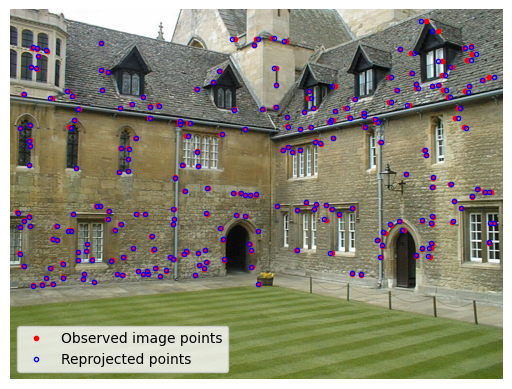

In [44]:
# Plotting the reprojection of X_for_P3 onto image 3
cam3_est = camera.Camera(P3)
x3_est = cam3_est.project(X_for_P3)

plt.figure()
plt.imshow(im1 if False else array(Image.open("./data/images/003.jpg")))
plt.plot(x3[0], x3[1], "r.", label="Observed image points")
plt.plot(x3_est[0], x3_est[1], "bo", markersize=3, fillstyle="none", label="Reprojected points")
plt.legend()
plt.axis("off")
plt.show()

## Part b: SSD stereo using filtering

The goal is to compute a disparity map from a stereo image pair using SSD, sum of squared differences. A disparity map stores, for each pixel, how far the pixel appears to shift between the left and the right image. This shift is related to depth: Pixels with larger disparity is closer to the camera.

In [49]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the left stereo image.
# The image is converted to grayscale using .convert("L"),
# because the SSD stereo function expects a single intensity value per pixel.
# dtype=float is used because later we subtract images and square differences.
im_l = np.array(Image.open("./data/tsukuba/scene1.row3.col3.ppm").convert("L"), dtype=float)

# Load the right stereo image, also as grayscale floating-point values.
im_r = np.array(Image.open("./data/tsukuba/scene1.row3.col4.ppm").convert("L"), dtype=float)

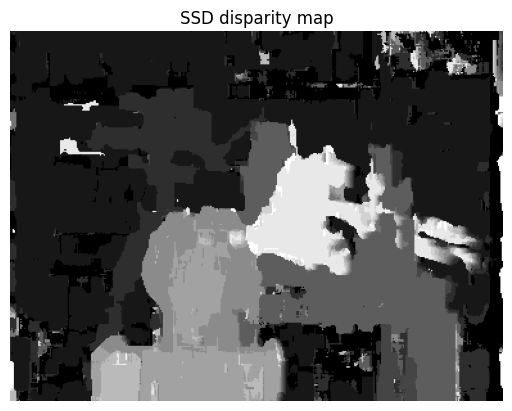

In [50]:
# Starting disparity.
# This means the algorithm starts by testing a horizontal shift of 4 pixels.
start = 4

# Number of disparity values to test.
# With start = 4 and steps = 12, the tested disparities are:
# 4, 5, 6, ..., 15
steps = 12

# Patch/window size.
# Here wid = 9 means that SSD is computed over a 9x9 local neighborhood.
# A larger window gives smoother but less detailed results.
# A smaller window gives sharper but noisier results.
wid = 9

# Compute the SSD disparity map.
# For each pixel, the function tests several disparities and chooses
# the disparity with the lowest SSD matching cost.
disp_ssd = stereo.plane_sweep_ssd(im_l, im_r, start, steps, wid)

plt.figure()
plt.imshow(disp_ssd, cmap="gray")
plt.title("SSD disparity map")
plt.axis("off")
plt.show()

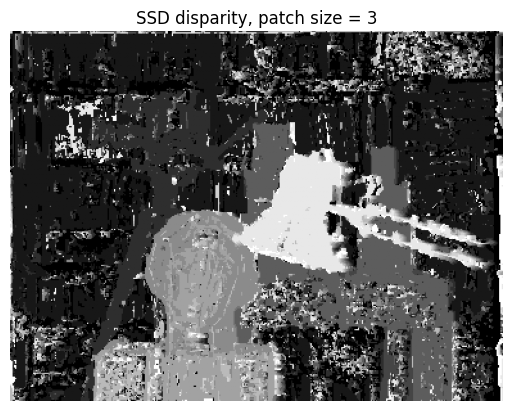

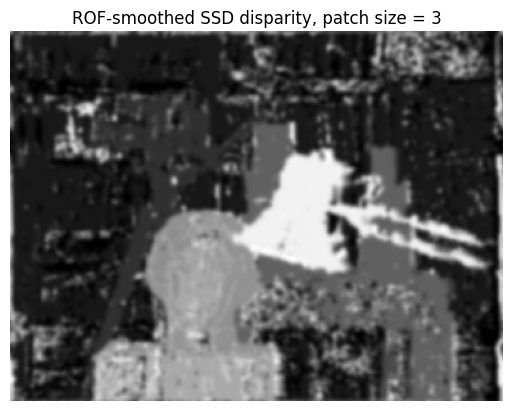

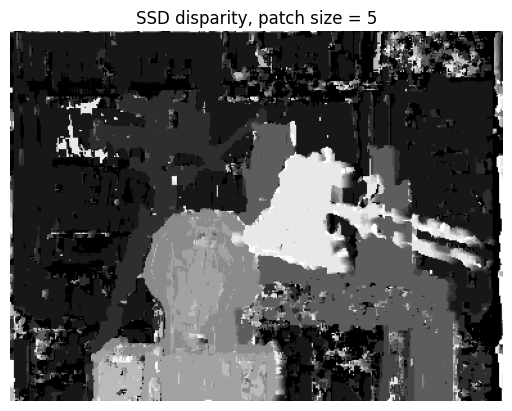

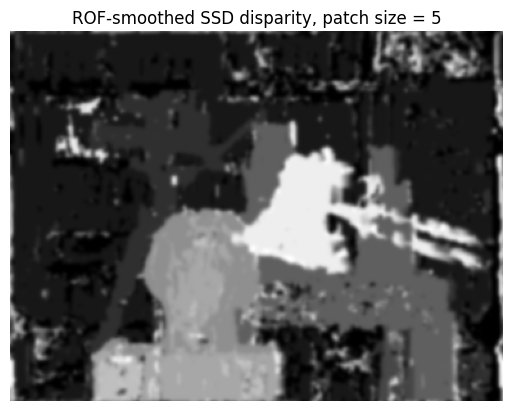

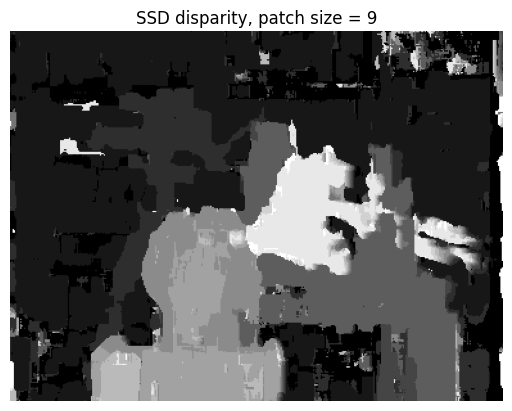

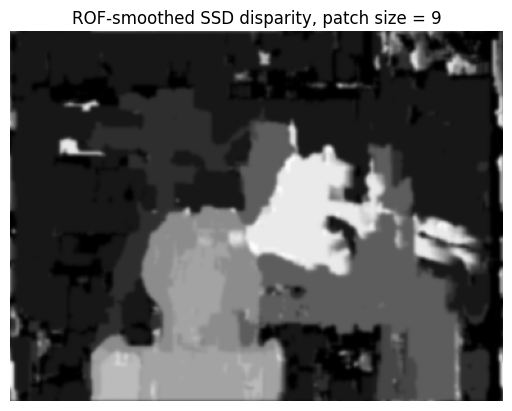

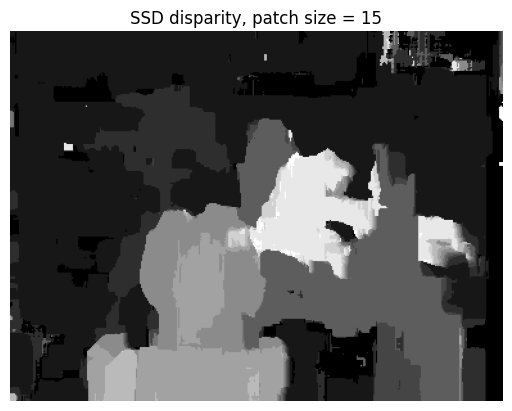

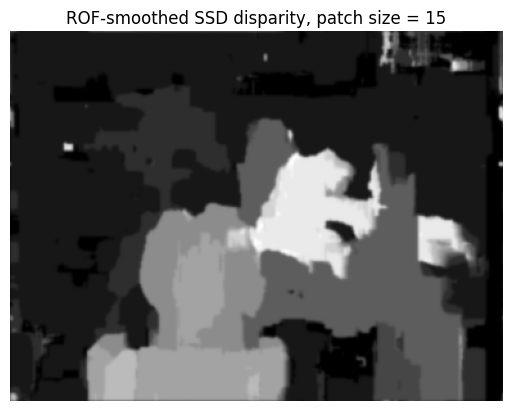

In [52]:
# Different patch sizes to test.
# This allows us to study how the matching window affects the disparity map.
patch_sizes = [3, 5, 9, 15]

import importlib
importlib.reload(stereo)

# Loop over each patch size.
for wid in patch_sizes:

    # Compute the SSD disparity map for the current patch size.
    # Smaller wid values usually give more noisy but sharper results.
    # Larger wid values usually give smoother but blurrier results.
    disp = stereo.plane_sweep_ssd(im_l, im_r, start=4, steps=12, wid=wid)

    # Apply ROF denoising to the disparity map.
    # ROF smoothing reduces noise while trying to preserve edges.
    #
    # tolerance = 0.05 controls when the iterative denoising stops.
    # tv_weight = 20 controls the smoothing strength.
    # Larger tv_weight generally gives stronger smoothing.
    disp_smooth = stereo.rof_denoise(disp, tolerance=0.05, tv_weight=20)

    plt.figure()
    plt.imshow(disp, cmap="gray")
    plt.title(f"SSD disparity, patch size = {wid}")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(disp_smooth, cmap="gray")
    plt.title(f"ROF-smoothed SSD disparity, patch size = {wid}")
    plt.axis("off")
    plt.show()

"""
What the output means:

bright areas = larger disparity
dark areas   = smaller disparity

larger disparity = closer object
smaller disparity = farther object

So the disparity map is a rough depth map.
"""